# Cuaderno 4: Plasticidad sináptica

La plasticidad sináptica es la capacidad de las conexiones entre neuronas (sinapsis) de cambiar su eficacia en función de la actividad. Dicho simple: el cerebro ajusta los pesos sinápticos según la experiencia, permitiendo aprender, recordar y adaptarse.

La plasticidad permite cambiar la probabilidad de que un potencial presináptico haga disparar a la neurona postsináptica. Lo puede lograr potenciando (LTP) o deprimiendo (LTD), y esos cambios pueden ser de corto o largo plazo. Hay muchas formas de que eso ocurra, una de ellas es debido al patrón temporal de disparos (p. ej., STDP: si la neurona presináptica dispara justo antes de la postsináptica, la sinapsis suele fortalecerse; si dispara después, suele debilitarse).

_Nota: Como veremos en el curso, en el contexto de modelos computacionales, "aprender" a menudo significa "ajustar pesos"._

En este cuaderno probaremos algunas reglas de plasticidad sináptica y sus consecuencias estadísticas.

## Configuración

En primer lugar, es necesario importar las librerias que vamos a utilizar. Corré la celda siguiente para hacerlo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from matplotlib.patches import Circle

### Funciones utilitarias

In [2]:
def generar_estimulo(n=64, n_frames=500, dt=0.015, velocidad=10.0, semilla=None):
    """
    Genera un estímulo visual naturalístico con correlaciones
    espacio-temporales de largo alcance.

    El estímulo se construye en el dominio de Fourier. La potencia espacial
    decrece aproximadamente como 1/k^2, de modo que las frecuencias
    espaciales bajas tienen mayor amplitud que las altas. Además, cada
    componente espacial evoluciona temporalmente con una constante de tiempo
    dependiente de su frecuencia.

    Esta implementación es una aproximación didáctica inspirada en el
    estímulo naturalístico utilizado por Pitkow y Meister (2012).

    Parameters
    ----------
    n : int, default=64
        Tamaño espacial de cada frame. Cada imagen generada tendrá dimensiones
        ``(n, n)``.

    n_frames : int, default=500
        Número total de frames del estímulo.

    dt : float, default=0.015
        Duración de cada frame, en segundos.

    velocidad : float, default=10.0
        Parámetro que controla la relación entre frecuencia espacial y
        correlación temporal. Valores mayores hacen que las componentes
        espaciales cambien más rápidamente.

    semilla : int or None, default=None
        Semilla para el generador de números aleatorios. Si es ``None``,
        se utiliza un estado aleatorio diferente en cada ejecución.

    Returns
    -------
    estimulo : ndarray of shape (n_frames, n, n)
        Secuencia de frames del estímulo. Cada frame está normalizado para
        tener aproximadamente media cero y desviación estándar uno.

    Notes
    -----
    Para una frecuencia espacial de magnitud ``k``, la potencia espacial se
    define aproximadamente como

    ``P(k) ∝ 1 / k^2``.

    La constante de tiempo de cada componente espacial se define como

    ``tau(k) = 1 / (k * velocidad)``.

    Esto hace que las estructuras espaciales grandes, correspondientes a
    frecuencias bajas, varíen más lentamente que los detalles espaciales
    pequeños.

    La componente de frecuencia espacial cero se elimina para evitar que la
    luminancia media global domine el estímulo.
    """
    rng = np.random.default_rng(semilla)

    # Frecuencias espaciales
    kx = np.fft.fftfreq(n)
    ky = np.fft.fftfreq(n)

    KX, KY = np.meshgrid(kx, ky)

    # Magnitud de la frecuencia espacial
    K = np.sqrt(KX**2 + KY**2)

    # Versión segura para evitar divisiones por cero
    K_safe = K.copy()
    K_safe[0, 0] = 1.0

    # Espectro de potencia espacial ~ 1/k²
    potencia = 1 / K_safe**2
    potencia[0, 0] = 0.0

    # Constante de tiempo dependiente de la frecuencia espacial
    tau = 1 / (K_safe * velocidad)

    # Correlación temporal entre frames consecutivos
    alpha = np.exp(-dt / tau)
    alpha[0, 0] = 0.0

    # Estado inicial en el dominio de Fourier
    F = np.zeros((n, n), dtype=complex)

    estimulo = np.zeros((n_frames, n, n))

    for t in range(n_frames):

        # Ruido gaussiano complejo
        ruido = (
            rng.standard_normal((n, n))
            + 1j * rng.standard_normal((n, n))
        )

        # Ajustar la amplitud de cada frecuencia espacial
        objetivo = ruido * np.sqrt(potencia)

        # Evolución temporal correlacionada
        F = (
            alpha * F
            + np.sqrt(1 - alpha**2) * objetivo
        )

        # Volver al dominio espacial
        frame = np.fft.ifft2(F).real

        # Normalización del contraste
        std = frame.std()

        if std > 0:
            frame = (frame - frame.mean()) / std
        else:
            frame = frame - frame.mean()

        estimulo[t] = frame

    return estimulo

def L(centro, n=64, sigma_center=2, sigma_surround=10, alpha=0.5):
    """
    Genera un campo receptivo bidimensional tipo center-surround mediante
    una diferencia de gaussianas.

    Parameters
    ----------
    centro : tuple of int
        Coordenadas ``(fila, columna)`` del centro del campo receptivo.

    n : int
        Tamaño espacial del campo receptivo. La salida tendrá dimensiones
        ``(n, n)``.
        
    sigma_center : float
        Desviación estándar de la gaussiana central, en píxeles. 2 por defecto.

    sigma_surround : float
        Desviación estándar de la gaussiana periférica, en píxeles. 10 por defecto.

    alpha : float
        Peso relativo del componente surround. Valores mayores aumentan la
        contribución inhibitoria de la periferia. 0.5 por defecto.

    Returns
    -------
    rf : ndarray of shape (n, n)
        Campo receptivo center-surround. Los valores positivos corresponden
        al centro excitatorio y los negativos al surround inhibitorio.
    """
    y0, x0 = centro
    y, x = np.mgrid[0:n, 0:n]
    g_center = np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma_center**2))
    g_surround = np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma_surround**2))
    g_center /= g_center.sum()
    g_surround /= g_surround.sum()
    rf = g_center - alpha * g_surround
    return rf

### Funciones de graficado

In [3]:
def visualizar_red(x, w):
    if w.ndim == 1:
        w = np.expand_dims(w, axis=0)
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")
    
    ax1.plot(x, label=["Célula 1", "Célula 2"])
    ax1.plot(x @ w[-1], label="Neurona post-sináptica")
    ax1.set_ylim(-2.5, 2.5)
    ax1.set_xlabel("Tiempo (s)")
    ax1.set_ylabel("Respuesta")
    ax1.legend()
    
    theta = np.linspace(0, 2 * np.pi, 200)
    ax2.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.2)
    ax2.set_xlim(-1.5, 1.5)
    ax2.set_ylim(-1.5, 1.5)
    ax2.set_xlabel("w₁")
    ax2.set_ylabel("w₂")
    ax2.set_title("Evolución de los pesos")
    ax2.axis("equal")

    n_pasos = len(w)
    if n_pasos == 1:
        snapshots = [0]
    else:
        indices = np.linspace(0, n_pasos - 1, min(10, n_pasos))
        snapshots = sorted(set(indices.astype(int)))

    cmap = plt.cm.Blues
    colores = [cmap(v) for v in np.linspace(0.3, 1.0, len(snapshots))]

    for idx, t in enumerate(snapshots):
        wx, wy = w[t]
        ax2.arrow(0, 0, wx, wy,
                  width=0.02, head_width=0.05,
                  color=colores[idx],
                  label=f"t = {t}")
    
    ax2.set_xlim(-1.5, 1.5)
    ax2.set_ylim(-1.5, 1.5)
    ax2.set_xlabel("w₁")
    ax2.set_ylabel("w₂")
    ax2.set_title("Pesos sinápticos")
    ax2.axis("equal")
    
    plt.show()

def visualizar_vector(v, lim=4):
  """ Dibuja un vector 2D

  Argumentos:
    v (ndarray): array de tamaño (2,) con las coordenadas del vector
  """
  fig, ax = plt.subplots()

  ax.spines['top'].set_color('none')
  ax.spines['bottom'].set_position('zero')
  ax.spines['left'].set_position('zero')
  ax.spines['right'].set_color('none')
  ax.grid(True, alpha=.4)

  v_arr = ax.arrow(0, 0, v[0], v[1], width=lim/50, head_width=lim / 20, length_includes_head=True)
  ax.set(xlim = [-lim, lim], ylim = [-lim, lim])

## Introducción a vectores

Consideremos primero un vector $\pmb{a}$ definido como:

$$ \pmb{a} = \begin{bmatrix} a_{1} \\ a_{2} \end{bmatrix} $$

Un vector se puede considerar desde al menos dos perspectivas: como una lista ordenada de números o como una flecha con la base en el origen de un sistema de coordenadas. Son dos maneras de mirar lo mismo: en el caso de la flecha, la punta está definida por una coordenada (que puede representarse con la lista ordenada).

La **dimensionalidad** de un vector está determinada por la cantidad de componentes en la lista ordenada (o por la dimensionalidad del espacio en el que existe la flecha). Decimos, entonces, que este vector de dos dimensiones tiene 2 componentes: $a_1$ y $a_2$.

Veamos como inicializar y visualizar un vector arbitrario en Numpy.

Esta representación vectorial no es solo matemática abstracta: en el contexto de las redes neuronales, un vector puede representar el estado de actividad de un conjunto de neuronas. En la siguiente sección vamos a ver exactamente eso.

In [4]:
a = np.array([0.2, 1])
print(a)

[0.2 1. ]


Cuando lo imprimimos, un vector no parece ser otra cosa que una lista ordenada. Generalmente, es mejor visualizarlo como una flecha en un espacio n-dimensional. Ejecutá la celda siguiente para visualizar este vector en un espacio de dos dimensiones:

In [5]:
@widgets.interact(a1=widgets.IntSlider(2, -4, 4, description="$a_{1}$"), a2=widgets.IntSlider(1, -4, 4, description="$a_{2}$"))
def interactive(a1, a2=1):
  visualizar_vector(np.array([a1, a2]))

interactive(children=(IntSlider(value=2, description='$a_{1}$', max=4, min=-4), IntSlider(value=1, description…

## Nuestra primera red neuronal

Definamos un modelo neuronal muy simple: un sistema de dos neuronas en el cual podemos medir su actividad. El vector $\pmb{x}$ define la actividad de las dos neuronas en un instante dado:

$$ \pmb{x} = \begin{bmatrix} 2 & 3 \end{bmatrix} $$

Tiene, entonces, dos componentes: $x_{1}$ y $x_{2}$. Uno para definir la actividad de cada neurona.

Agreguemos una tercera neurona, la neurona post-sináptica, cuya actividad esté mediada por la actividad de del sistema de neuronas recién definido. Para modelar la influencia que cada neurona pueda tener sobre esta tercera neurona, podemos definir un segundo vector $\pmb{w}$:

$$ \pmb{w} = \begin{bmatrix} 1 \\ 4 \end{bmatrix} $$

donde sus compontentes, $w_{1}$ y $w_{2}$, modelan el peso que tiene cada neurona $x_{1}$ y $x_{2}$ respectivamente sobre esta tercera neurona.

La actividad de esta tercera neurona se puede modelar como el **producto escalar** entre estos dos vectores:

$$ \pmb{x} \cdot \pmb{w} = x_{1} w_{1} + x_{2} w_{2} = 2 \times 1 + 3 \times 4 = 14 $$

Veamos como hacerlo en Python:

In [6]:
x = np.array([2, 3])
w = np.array([1, 4])

print(x @ w)

14


Para modelar la actividad de las tres neuronas a lo largo del tiempo, podemos extender nuestros vectores a matrices (también se pueden ver los vectores como un caso especial de las matrices) agregando una dimensión tiempo. Por ejemplo, la actividad de las dos neuronas presinápticas a lo largo de tres instantes temporales puede especificarse como:

$$ \pmb{x} = \begin{bmatrix} 2 & 3 \\ 4 & 5 \\ 0 & 2 \end{bmatrix} $$

Dado el mismo vector de pesos sinápticos, ¿cómo podemos calcular la actividad de la neurona postsináptica a lo largo del tiempo? Una ventaja muy importante del álgebra lineal es que nos permite hacer estos cálculos haciendo exactamente la misma operación:

In [7]:
x = np.array([[2, 3], [4, 5], [0, 2]])
w = np.array([1, 2])

print(x @ w)

[ 8 14  4]


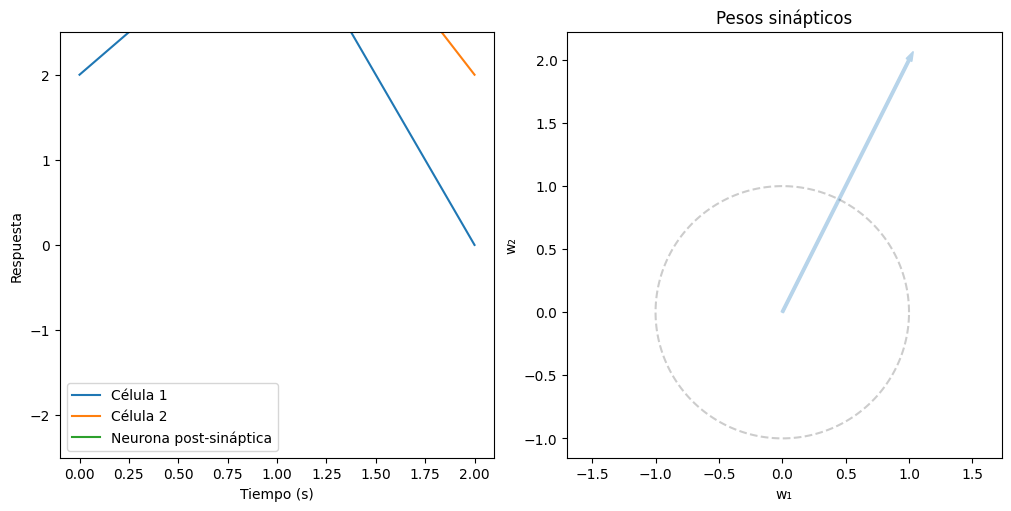

In [8]:
visualizar_red(x, w)

## Modelo simple de visión

Podemos seguir trabajando con números abstractos (carentes de un correlato) para estudiar la plasticidad sináptica. Sin embargo, es más interesante verla en un contexto más cercano a la realidad de nuestro sistema nervioso. Para eso, crearemos ejemplos naturalísticos de escenas visuales que nuestra retina normalmente percibe, utilizaremos un modelo de campos receptivos para simular una actividad lineal de dos células ganglionares en la retina, y exploraremos como una neurona, conectada a estas dos células, puede cambiar su eficacia según la actividades de las dos células. Si bien elegimos un ejemplo de la visión (tendremos una clase más adelante en el curso centrada en este tema), podríamos haber elegido cualquier grupo de neuronas para estudiar la plasticidad.

Primero generemos un número $N$ de escenas visuales (estímulos) que simboliza una escena natural que puede estar viendo nuestra retina a lo largo de un tiempo arbitrario.

> **Observá y respondé:**
>
> 1. ¿Cómo se comparan regiones cercanas en el espacio con regiones lejanas?
> 2. ¿Cómo se compara una misma región en escenas cercanas en el tiempo versus escenas lejanas?

In [9]:
N = 500
SEED = 0

estimulos = generar_estimulo(n_frames=N, semilla = SEED)

@widgets.interact(t = (0, N-1))
def visualizar_estimulo(t = 0):
    estimulo = estimulos[t]
    
    fig, ax = plt.subplots(layout='constrained', figsize=(4, 4))
    ax.set_title(f"Estímulo (t={t})")
    ax.imshow(estimulo, cmap="gray")
    plt.show()

interactive(children=(IntSlider(value=0, description='t', max=499), Output()), _dom_classes=('widget-interact'…

Ahora generaremos la actividad de dos células ganglionares vecinas. Modelamos cada célula como un filtro lineal espacial aplicado al estímulo — la respuesta lineal es el producto punto entre el estímulo y el campo receptivo de la célula. Esta aproximación lineal es la que utilizan Linsker (1988) y Oja (1982) en sus modelos de plasticidad sináptica.

Dos células vecinas comparten parte de su campo receptivo y por lo tanto responden de forma correlacionada al mismo estímulo. Esa correlación es la que nuestra neurona post-sináptica, que aprende de forma no supervisada, aprenderá a detectar.

Modifica `centro1` y `centro2` de tal manera que la correlación entre las regiones sea entre 0.4 y 0.5.

In [10]:
centro1 = np.array([32, 28])
centro2 = np.array([32, 32])

campo1 = L(n=64, centro=centro1)
campo2 = L(n=64, centro=centro2)

respuesta1 = np.sum(estimulos * campo1, axis=(1, 2))
respuesta2 = np.sum(estimulos * campo2, axis=(1, 2))

print(f"Distancia entre campos receptivos: {np.linalg.norm(centro2 - centro1)} píxeles")
print(f"Correlación entre respuestas: {np.corrcoef(respuesta1, respuesta2)[0, 1]:.3f}")

@widgets.interact(t = (0, N-1))
def visualizar_estimulos(t = 0):
    estimulo = estimulos[t]
    
    fig, axes = plt.subplot_mosaic([['a', 'b', 'c'], ["d", "d", "e"]], layout='constrained', figsize=(10, 6))

    axes["a"].set_title(f"Estímulo (t={t})")
    axes["a"].imshow(estimulo, cmap="gray")
    axes["a"].add_patch(Circle(centro1[::-1], radius=3, fill=False, color="tab:blue", label="Célula 1"))
    axes["a"].add_patch(Circle(centro2[::-1], radius=3, fill=False, color="tab:orange", label="Célula 2"))
    axes["a"].legend()

    axes["b"].set_title("Campo receptivo (célula 1)")
    axes["b"].imshow(estimulo * campo1, cmap="gray", vmin=-0.05, vmax=0.05)

    axes["c"].set_title("Campo receptivo (célula 2)")
    axes["c"].imshow(estimulo * campo2, cmap="gray", vmin=-0.05, vmax=0.05)

    axes["d"].set_title("Actividades lineales")
    axes["d"].plot(respuesta1, label="Célula 1")
    axes["d"].plot(respuesta2, label="Célula 2")
    axes["d"].set_xlabel("Tiempo")
    axes["d"].set_ylabel("Respuesta")
    axes["d"].axvline(t, color="tab:green")
    axes["d"].legend()

    axes["e"].set_title("Actividades lineales")
    axes["e"].scatter(respuesta1, respuesta2, alpha=0.4, color="tab:green")
    axes["e"].scatter(respuesta1[t], respuesta2[t], color="tab:red")
    axes["e"].set_xlabel("Célula 1")
    axes["e"].set_ylabel("Célula 2")
    axes["e"].axis("equal")
    
    plt.show()

Distancia entre campos receptivos: 4.0 píxeles
Correlación entre respuestas: 0.829


interactive(children=(IntSlider(value=0, description='t', max=499), Output()), _dom_classes=('widget-interact'…

Si las dos respuestas están correlacionadas, los puntos del panel derecho deberían alinearse a lo largo de una dirección preferencial en el espacio de actividades.

A continuación introducimos la neurona post-sináptica en nuestro modelo. Sus conexiones con las dos células presinápticas quedan representadas por el vector de pesos $\pmb{w} = (w_1, w_2)$. La actividad de la neurona postsináptica es $y = w_1 x_1 + w_2 x_2$, es decir, una combinación lineal de las dos células.

Para saber si un vector de pesos es bueno, podemos medir cuánto se parece la actividad de la neurona postsináptica a la de cada célula presináptica, usando la correlación de Pearson. Si los pesos apuntan en la dirección correcta, la neurona debería correlacionar bien con ambas células a la vez.

> **Actividad 1:** usá los sliders para encontrar los valores de $w_1$ y $w_2$ que maximizan la correlación de la neurona postsináptica con las dos células.
>
> 1. ¿Qué valores de $w_1$ y $w_2$ maximizan la correlación con ambas células simultáneamente?
> 2. ¿Cambia la solución si modificás la distancia entre los centros de los campos receptivos?
> 3. **Anotá los valores de $w_1$ y $w_2$ que encontraste** — los vas a comparar más adelante con los que encuentre la regla de aprendizaje.

In [11]:
X = np.stack([respuesta1, respuesta2], axis=1)

@widgets.interact(w1=(-1, 1, 0.05), w2=(-1, 1, 0.05))
def simulate(w1=-0.2, w2=0.5):
    w = np.array([w1, w2])
    output = X @ w
    r1 = np.corrcoef(output, respuesta1)[0, 1]
    r2 = np.corrcoef(output, respuesta2)[0, 1]
    print(f"Correlación con célula 1: {r1:.3f}")
    print(f"Correlación con célula 2: {r2:.3f}")
    visualizar_red(X, w)


interactive(children=(FloatSlider(value=-0.2, description='w1', max=1.0, min=-1.0, step=0.05), FloatSlider(val…

## Regla hebbiana

En el sistema nervioso, no hay ninguna señal de supervisión que le diga exactamente que pesos sinápticos debe tener una neurona post-sináptica. Entonces, ¿cómo puede encontrar los pesos por su propia cuenta? Es esta la clase de preguntas es la que aborda el aprendizaje no supervisado. O, planteado de otra forma, ¿cómo podemos ajustar los pesos para modelar la plasticidad?

Una regla hebbiana básica se escribe como:

$$ \Delta w = \eta x_{pre} x_{post} $$

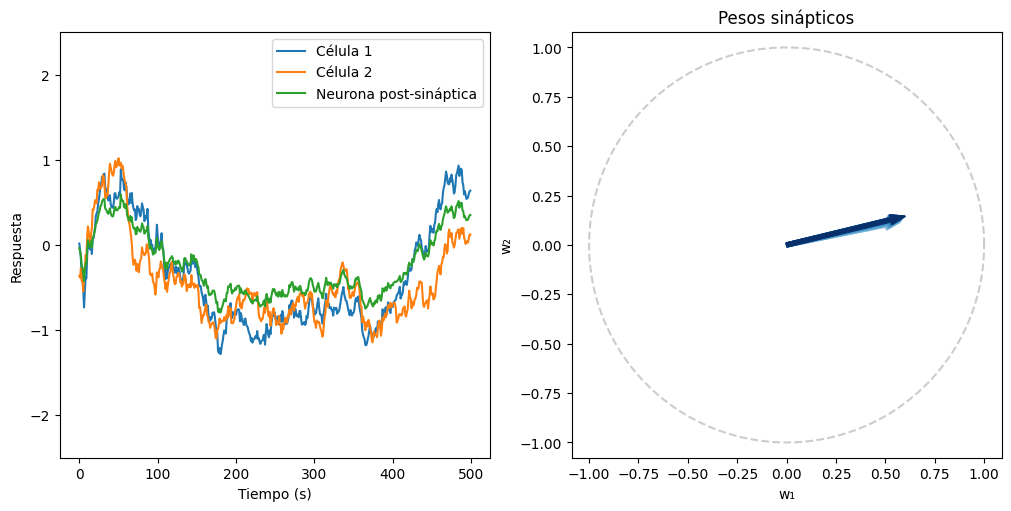

In [12]:
# Cantidad de estímulos a usar en el entrenamiento
# No puede ser mayor a N
T = 100

# Tasa de aprendizaje
eta = 0.002

# Matriz con el historial de los pesos sinápticos que va a ir aprendiendo la red
W = np.empty((T + 1, 2))

# Valor inicial de los pesos sinápticos
W[0] = np.array([0.5, 0.1])

for i in range(T):
    x_pre = X[i]
    x_post = x_pre @ W[i]
    W[i+1] = W[i] + eta * x_post * x_pre

visualizar_red(X, W)

In [13]:
w = W[-1]

theta = np.arctan2(w[1], w[0])
score = np.sin(2 * theta)

print("Pesos sinápticos:", w)
print("Norma de los pesos sinápticos:", np.linalg.norm(w))
print(f"Ángulo: {theta}")
print(f"Correlación aprendida: {score}")

Pesos sinápticos: [0.52795118 0.12778296]
Norma de los pesos sinápticos: 0.5431951188424113
Ángulo: 0.2374687780261082
Correlación aprendida: 0.4572829153390805


> **Actividad 2:**
>
> 1. Probá con diferentes pesos iniciales. ¿El resultado final depende de dónde arrancás?
> 2. Probá cambiando $T$. ¿Qué pasa cuando es muy chico? ¿Y cuando es muy grande?

> **Para pensar antes de seguir:** ejecutá la celda de Hebb con un $T$ grande (por ejemplo, $T = 300$) y observá la norma de los pesos sinápticos en la salida. ¿Qué le pasa a $\|\pmb{w}\|$ a medida que avanza el entrenamiento? ¿Es eso un problema? ¿Cómo lo resolverías?

## Regla de Oja

Si corriste la celda anterior, habrás notado que los pesos crecen indefinidamente. Esto es un problema fundamental de la regla hebbiana pura: como el término $x_{pre} x_{post}$ siempre refuerza la sinapsis cuando hay actividad correlacionada, no hay nada que frene el crecimiento.

Oja (1982) propuso una solución elegante: agregar un término que normalice los pesos en función de la actividad postsináptica:

$$ \Delta w = \eta (x_{pre} x_{post} - x_{post}^2 w) $$

El primer término $\eta \, x_{pre} \, x_{post}$ es la regla hebbiana de siempre. El segundo término $\eta \, x_{post}^2 \, w$ es una depresión proporcional al peso actual: cuanto más grandes los pesos, más fuerte la depresión. Estos dos términos se equilibran cuando la norma del vector de pesos $\|w\|$ converge a 1, independientemente de los valores iniciales.

Linsker (1988) mostró que esta regla tiene una interpretación funcional precisa: la neurona post-sináptica desarrolla pesos que maximizan la varianza de su output, sujeto a la restricción $\|w\| = 1$. Y maximizar la varianza del output equivale a encontrar el primer componente principal de la actividad presináptica — es decir, la dirección en el espacio de actividades que captura la mayor covarianza entre las dos neuronas.

En nuestro caso, esa dirección refleja la correlación entre las dos células ganglionares vecinas, que a su vez surge de que sus campos receptivos se solapan y responden a las mismas estructuras del estímulo visual.

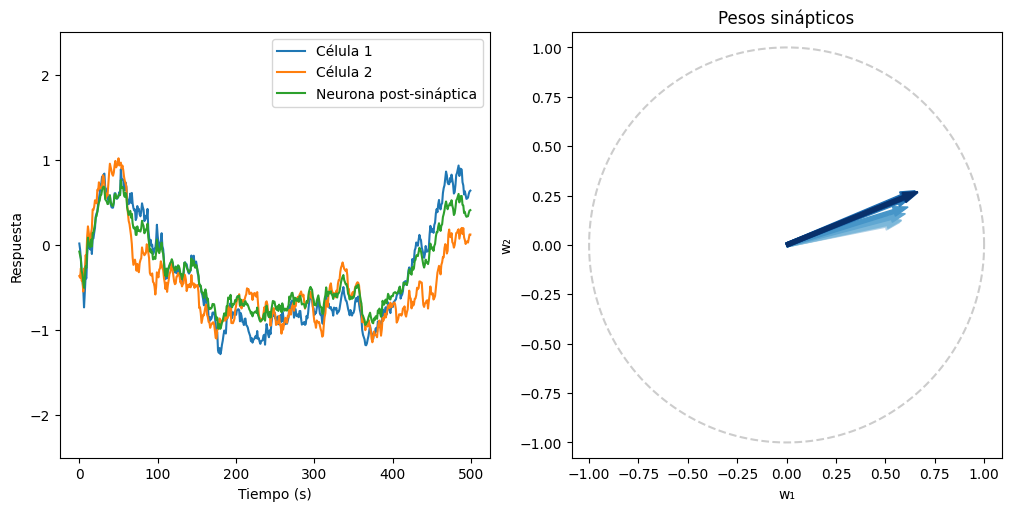

In [14]:
# Cantidad de estímulos a usar en el entrenamiento
# No puede ser mayor a N
T = 100

# Tasa de aprendizaje
eta = 0.01

# Matriz con el historial de los pesos sinápticos que va a ir aprendiendo la red
W = np.empty((T + 1, 2))

# Valor inicial de los pesos sinápticos
W[0] = np.array([0.5, 0.1])

for i in range(T):
    x_pre = X[i]
    x_post = x_pre @ W[i]
    W[i+1] = W[i] + eta * (x_post * x_pre - x_post ** 2 * W[i])

visualizar_red(X, W)

In [15]:
w = W[-1]

theta = np.arctan2(w[1], w[0])
score = np.sin(2 * theta)

print("Pesos sinápticos:", w)
print("Norma de los pesos sinápticos:", np.linalg.norm(w))
print(f"Ángulo: {theta}")
print(f"Correlación aprendida: {score}")

Pesos sinápticos: [0.59512331 0.24153192]
Norma de los pesos sinápticos: 0.6422689620000586
Ángulo: 0.3855409064855716
Correlación aprendida: 0.6969114762001624


> **Actividad 3:**
>
> 1. Probá cambiando $\eta$. ¿Qué pasa cuando es muy chico? ¿Y cuando es muy grande?
> 2. ¿Cuántos pasos $T$ necesita Oja para converger comparado con Hebb?
> 3. **Compará los pesos que encontró la regla de Oja con los que anotaste en la Actividad 1.** ¿Son similares? ¿Qué te dice eso sobre lo que está haciendo la regla de plasticidad?

## Actividad de cierre

Ahora que los pesos convergieron (nuestra neurona post-sináptica aprendió algo), pensá en la siguiente situación: una de las dos células ganglionares presinápticas deja de funcionar. Por ejemplo, por daño en la retina.

Anotá en la celda siguiente los valores de pesos sinápticos que encontraste:

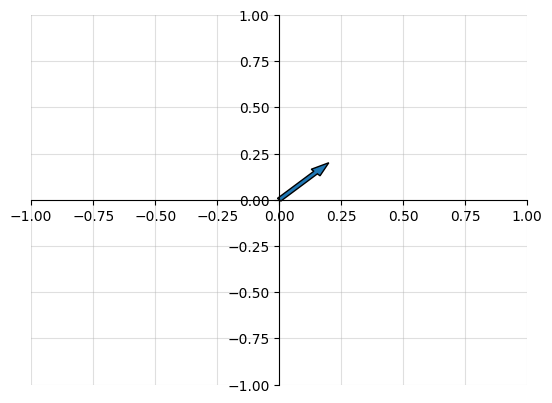

In [16]:
w = np.array([0.2, 0.2])
visualizar_vector(w, lim=1)

Ahora definiremos un conjunto de actividades $X$ alternativo, llamado $X_{ablación}$ que modele una de las dos células ganglionares apagada. Es decir, su actividad es nula en el tiempo.

In [17]:
X_ablacion = X.copy()
X_ablacion[:, 0] = 0

Usa las funciones `np.shape` y `print` para entender mejor lo que estamos haciendo. ¿Cómo se compara con $X$?

In [18]:
# Celda en blanco a propósito

¿Qué esperarías que le pase a la actividad de la neurona post-sináptica en este escenario? Tené en cuenta:

* La correlación entre las dos células presinápticas que calculamos antes
* El valor de los pesos aprendidos
* Qué representa geométricamente el vector $\pmb{w}$

Probá apagando la otra célula.

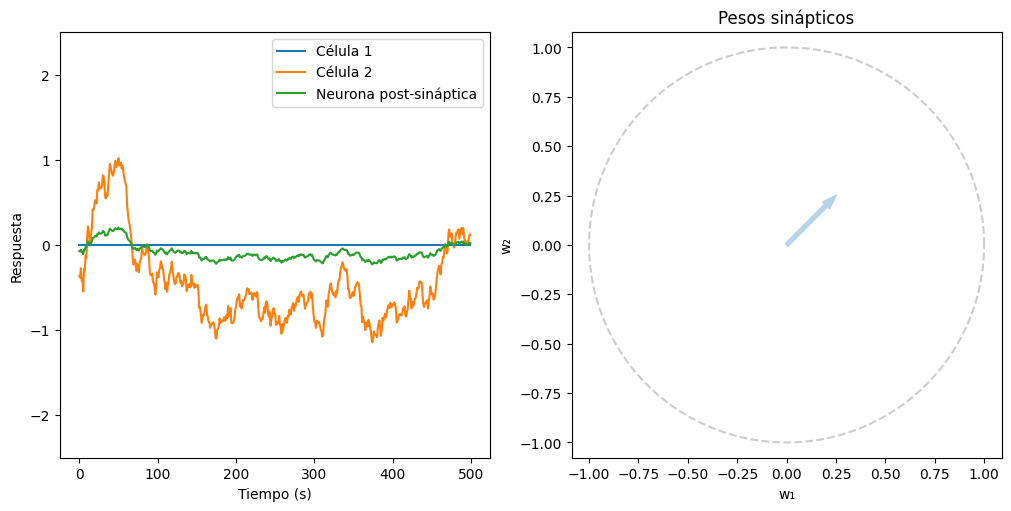

In [20]:
visualizar_red(X_ablacion, w)